In [41]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import igraph as ig
import leidenalg as la

In [14]:
def iter_coordinates_by_time(df):
    """
    Create an iterator that yields timestamp and coordinate matrices for each timestamp.
    Each matrix contains all X,Y points for a single timestamp.
    
    Parameters:
    df (pandas.DataFrame): DataFrame with X, Y, and Time columns
    
    Yields:
    tuple: (time, numpy.ndarray) where time is the timestamp and 
           numpy.ndarray is a matrix of X,Y coordinates for that timestamp
    """
    # Validate input columns
    required_cols = ['X', 'Y', 'Time']
    if not all(col in df.columns for col in required_cols):
        raise ValueError(f"DataFrame must contain {required_cols} columns")
    
    # Sort the unique timestamps
    sorted_times = sorted(df['Time'].unique())
    
    # Group by time and yield matrices in sorted order
    for time in sorted_times:
        # Get rows for this timestamp
        group = df[df['Time'] == time]
        # Extract X and Y columns as a matrix
        coordinates = group[['X', 'Y']].values
        yield time, coordinates

In [31]:
import numpy as np
import networkx as nx
from sklearn.neighbors import NearestNeighbors

def build_knn_graph(coordinates, k=5, include_self=False):
    """
    Build a k-nearest neighbors graph from a matrix of coordinates.
    
    Parameters:
    -----------
    coordinates : numpy.ndarray
        A matrix of shape (n_points, 2) containing X,Y coordinates
    k : int, default=5
        Number of nearest neighbors to find for each point
    include_self : bool, default=False
        Whether to include self-connections in the graph
        
    Returns:
    --------
    networkx.Graph
        A graph where nodes are indices of points and edges connect to k-nearest neighbors
    """
    # Handle edge cases
    n_points = coordinates.shape[0]
    if n_points <= 1:
        return nx.Graph()
        
    # Adjust k if needed
    actual_k = min(k + (0 if include_self else 1), n_points)
    
    # Find k nearest neighbors for each point
    nbrs = NearestNeighbors(n_neighbors=actual_k, algorithm='ball_tree').fit(coordinates)
    distances, indices = nbrs.kneighbors(coordinates)
    
    # Create graph
    G = nx.Graph()
    
    # Add nodes with coordinate attributes
    for i in range(n_points):
        G.add_node(i, pos=(coordinates[i, 0], coordinates[i, 1]))
    
    # Add edges
    for i in range(n_points):
        # Skip the first neighbor if it's the point itself and we don't want self-connections
        start_idx = 1 if not include_self else 0
        for j in range(start_idx, len(indices[i])):
            neighbor_idx = indices[i, j]
            # Add edge with distance as weight
            G.add_edge(i, neighbor_idx, weight=distances[i, j])
    
    return G

In [58]:
import numpy as np
import igraph as ig
from sklearn.neighbors import NearestNeighbors

def build_knn_igraph(coordinates, k=5, include_self=False, symmetric=True):
    """
    Build a k-nearest neighbors graph from coordinates using igraph (optimized version).
    
    Parameters:
    -----------
    coordinates : numpy.ndarray
        Matrix of shape (n_points, 2) containing X,Y coordinates
    k : int, default=5
        Number of nearest neighbors for each point
    include_self : bool, default=False
        Whether to include self-connections
    symmetric : bool, default=True
        Whether to ensure symmetric connections (i→j means j→i exists too)
        
    Returns:
    --------
    igraph.Graph
        An undirected graph connecting k-nearest neighbors
    """
    n_points = coordinates.shape[0]
    if n_points <= 1:
        return ig.Graph()
        
    # Adjust k based on parameters
    actual_k = min(k + (0 if include_self else 1), n_points)
    
    # Use efficient ball_tree algorithm for nearest neighbors
    # Increased n_jobs for parallel processing
    nbrs = NearestNeighbors(n_neighbors=actual_k, algorithm='ball_tree', n_jobs=-1).fit(coordinates)
    distances, indices = nbrs.kneighbors(coordinates)
    
    # Create graph with pre-allocated vertices
    G = ig.Graph(n=n_points)
    
    # Add vertex coordinates in bulk
    G.vs["x"] = coordinates[:, 0]
    G.vs["y"] = coordinates[:, 1]
    
    # Use numpy for efficient edge list creation
    start_idx = 1 if not include_self else 0
    rows, cols = np.nonzero(np.ones((n_points, actual_k - start_idx)))
    
    sources = rows
    targets = indices[rows, cols + start_idx]
    weights = distances[rows, cols + start_idx]
    
    # Pre-allocate edge list array for better performance
    edge_list = np.column_stack((sources, targets))
    
    # Add all edges at once
    G.add_edges(edge_list)
    G.es["weight"] = weights
    
    if symmetric:
        # Make graph undirected (ensures symmetry in kNN relationships)
        G.simplify(combine_edges=dict(weight="min"))
    
    return G

In [32]:
df = pd.read_csv('df_all_new.csv')

In [33]:
coord_timesteps_iter = iter_coordinates_by_time(df)

In [34]:
coord_timesteps = list(coord_timesteps_iter)

In [ ]:
knn_graph_nx = build_knn_graph(coord_timesteps[0][1], k=200, include_self=False)

In [75]:
#knn_graph_ig = ig.Graph.from_networkx(knn_graph_nx)
knn_graph_ig = build_knn_igraph(coord_timesteps[-1][1], k=10, include_self=False, symmetric=True)

In [76]:
partition = la.find_partition(knn_graph_ig, la.ModularityVertexPartition, n_iterations=50)

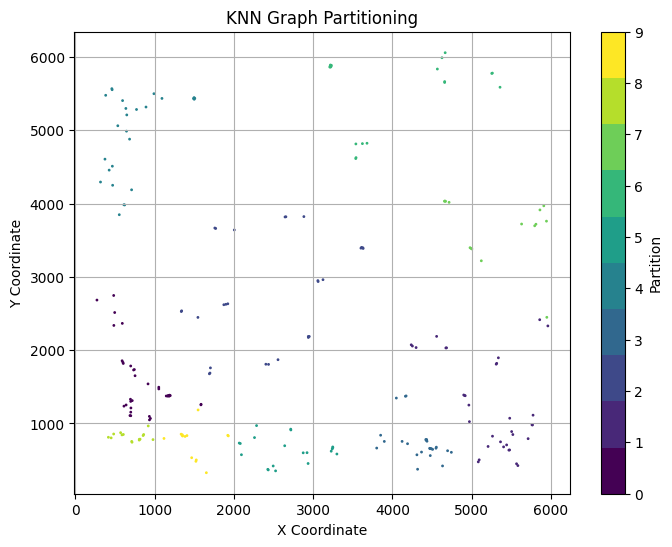

In [78]:
# plot points colored by partition

points = coord_timesteps[-1][1]
partitions = partition.membership
# Create a color map
cmap = plt.get_cmap('viridis', max(partitions) + 1)
# Create a scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(points[:, 0], points[:, 1], c=partitions, cmap=cmap, s=1)
plt.colorbar(label='Partition')
plt.title('KNN Graph Partitioning')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.grid()
plt.show()

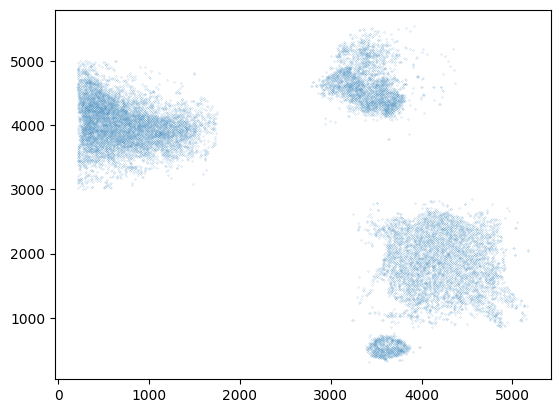

In [ ]:
for t, m in coord_timesteps:
    #plt.plot(m[:, 0], m[:, 1], 'o', markersize=0.1)
    #break

In [ ]:
import igraph

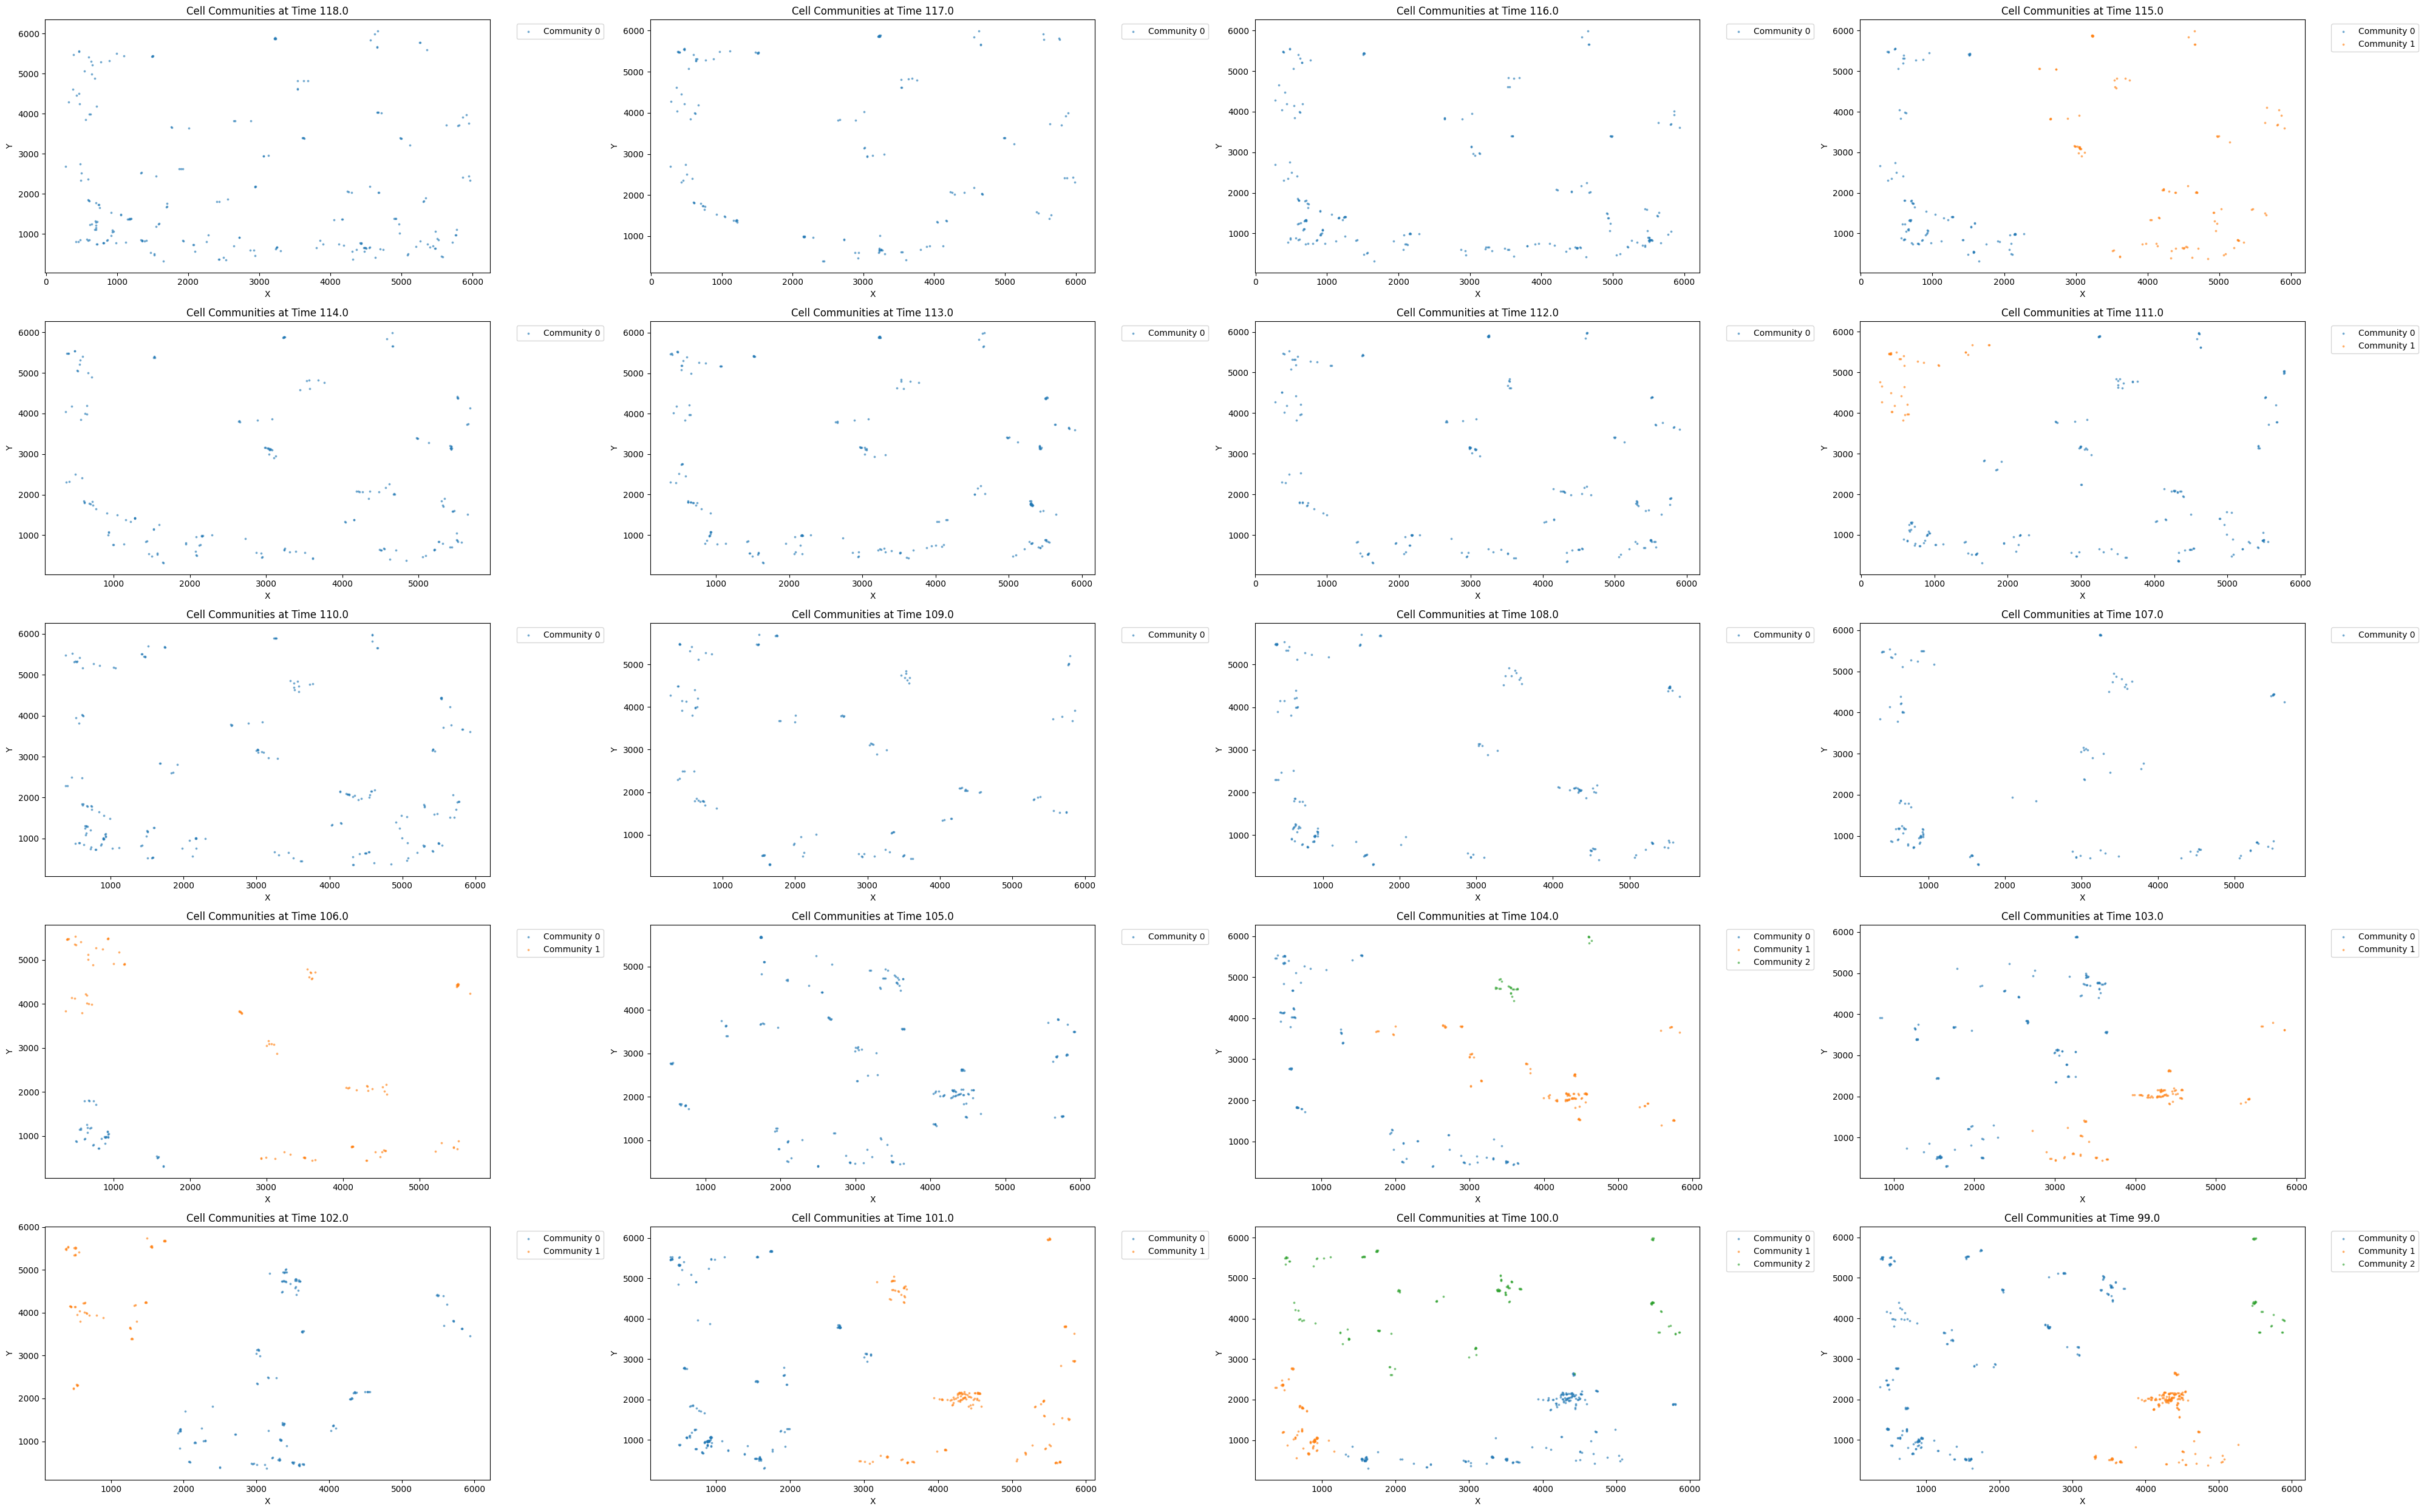

In [2]:
import sys
import pandas as pd
sys.path.append('/home/kidara/raid/volume/Cellgroup/notebooks/clustering')

from clustering_utils import iter_trajectory_analysis, plot_all_trajectories

# Load your data
df = pd.read_csv('/home/kidara/raid/volume/Cellgroup/notebooks/clustering/df_all_new.csv')
#df = df[df['Time'] < 70]

# Plot all trajectories
plot_all_trajectories(df, k_graph=20, k_mapping=5, max_plots=20, resolution=0.05)

# # Or process trajectories manually
# for time, coords, membership in iter_trajectory_analysis(df):
#     # Custom processing here
#     print(f"Time {time}: {len(np.unique(membership))} communities")